🔌 Connecting DeepDrift to Transformer...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ Calibrating on normal users...
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.

💳 Processing Good User Stream...

💳 Processing Hacked User Stream...


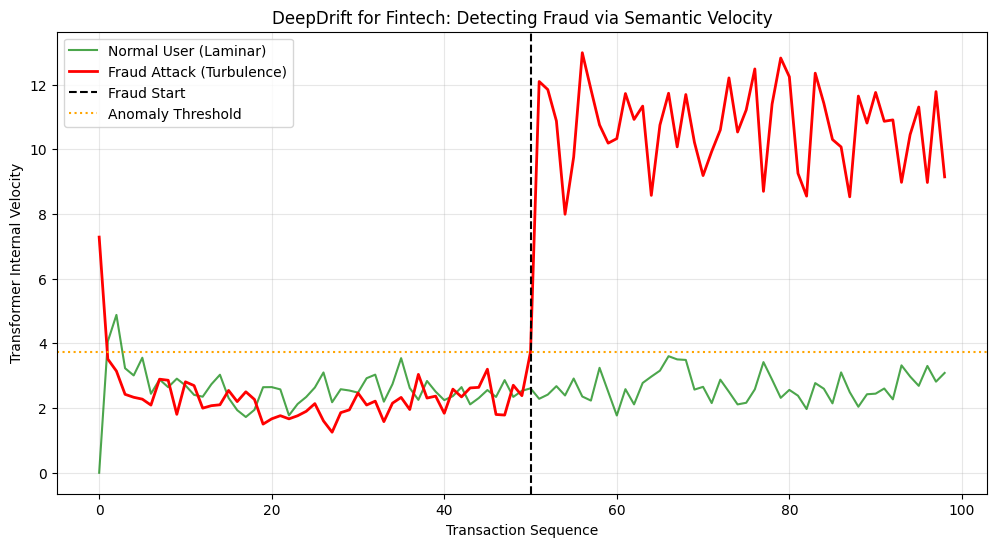

In [2]:
# --- 1. SETUP ---
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deepdrift import DeepDriftMonitor

# --- 2. DATA SIMULATOR ---
def generate_user_history(n_steps=100, mode="normal"):
    data = []
    current_state = np.zeros(32)

    for i in range(n_steps):
        if mode == "normal":
            noise = np.random.normal(0, 0.1, 32)
            current_state = current_state * 0.9 + noise
        elif mode == "fraud":
            if i > 50:
                noise = np.random.normal(0, 2.0, 32)
                current_state = noise
            else:
                noise = np.random.normal(0, 0.1, 32)
                current_state = current_state * 0.9 + noise
        data.append(current_state)

    return torch.tensor(np.array(data), dtype=torch.float32).unsqueeze(0)  # [1, Seq, 32]

# --- 3. MODEL: Time-Series Transformer ---
class TransactionTransformer(nn.Module):
    def __init__(self, input_dim=32, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.head = nn.Linear(d_model, input_dim)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.head(out)

model = TransactionTransformer()
model.eval()

# --- 4. DEEPDRIFT SETUP ---
print("🔌 Connecting DeepDrift to Transformer...")

# Мониторим последний слой трансформера
layers_map = {"Transformer_Encoder": model.transformer.layers[-1]}
monitor = DeepDriftMonitor(model, layers_map=layers_map, strategy="last_token")

# --- 5. REAL-TIME PROCESSING LOOP ---
def process_transaction_stream(user_data, label="Normal"):
    print(f"\n💳 Processing {label} User Stream...")

    history = {'velocity': []}
    seq_len = user_data.shape[1]

    # Обрабатываем по одному токену (как в реальном времени)
    for t in range(1, seq_len):  # Начинаем с t=1, чтобы было h_t и h_{t-1}
        tx_seq = user_data[:, :t, :]  # Последовательность до текущего шага

        # MONITOR STEP
        status, _ = monitor.step(tx_seq)
        vel = status['Transformer_Encoder']['velocity']
        history['velocity'].append(vel)

    return history['velocity']

# --- 6. EXECUTION ---
print("⚙️ Calibrating on normal users...")
calib_batch = [generate_user_history(mode="normal") for _ in range(10)]
monitor.calibrate(calib_batch)

# Test
good_user = generate_user_history(mode="normal")
bad_user = generate_user_history(mode="fraud")

vel_good = process_transaction_stream(good_user, "Good")
vel_bad = process_transaction_stream(bad_user, "Hacked")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(vel_good, label="Normal User (Laminar)", color="green", alpha=0.7)
plt.plot(vel_bad, label="Fraud Attack (Turbulence)", color="red", linewidth=2)
plt.axvline(x=50, color='black', linestyle='--', label="Fraud Start")
plt.axhline(y=np.mean(vel_good) + 2*np.std(vel_good), color='orange', linestyle=':', label="Anomaly Threshold")
plt.title("DeepDrift for Fintech: Detecting Fraud via Semantic Velocity")
plt.ylabel("Transformer Internal Velocity")
plt.xlabel("Transaction Sequence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

⚙️ Re-Calibrating on stealth baseline...
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
⚔️ Running Stealth Attack Test...
⚔️ Running SOTA Comparison...


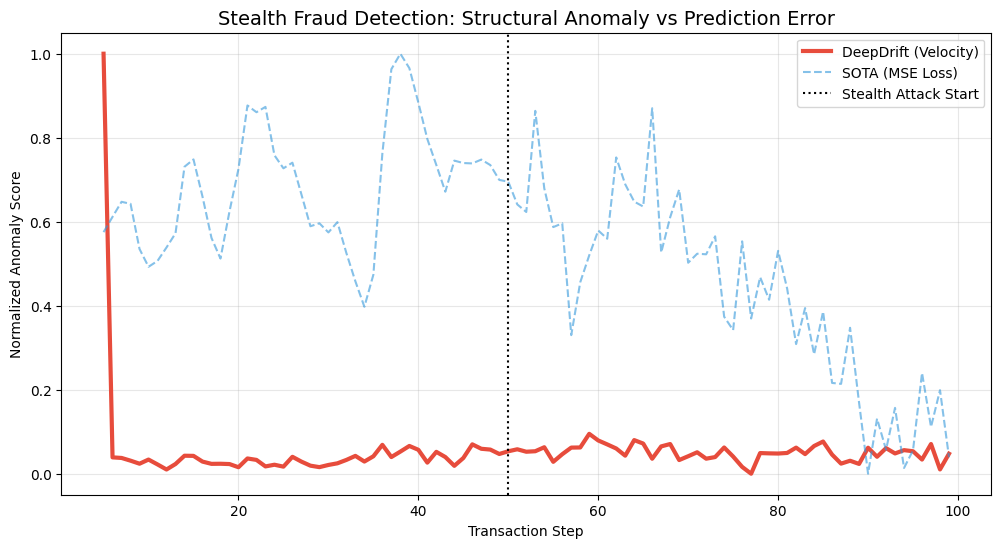


🏆 STEALTH RESULTS:
   SOTA (MSE):      0.78x
   DeepDrift (Vel): 0.97x


In [5]:
# --- 1. CONFIG ---
# (Оставляем те же импорты и модель, меняем только данные)

# --- 2. DATA SIMULATOR (Stealth Edition) ---
def generate_user_history(n_steps=100, mode="normal"):
    data = []
    # Нормальный вектор интересов
    state = np.zeros(INPUT_DIM)

    # Генерируем "нормальный" пул транзакций для перемешивания
    # Чтобы амплитуда была "легальной"
    legit_pool = [np.random.normal(0, 0.1, INPUT_DIM) for _ in range(10)]

    for i in range(n_steps):
        if mode == "normal":
            # Плавная эволюция (Smooth Random Walk)
            # Пользователь последователен
            noise = np.random.normal(0, 0.05, INPUT_DIM)
            state = state * 0.95 + noise
        elif mode == "fraud":
            if i >= 50:
                # STEALTH ATTACK:
                # Амплитуда нормальная (не палится по сумме), но ЛОГИКА сломана.
                # Мы просто рандомно дергаем транзакции из пула "нормальных".
                # Нет плавности, нет истории. "Рваный ритм".
                state = random.choice(legit_pool)
            else:
                noise = np.random.normal(0, 0.05, INPUT_DIM)
                state = state * 0.95 + noise
        data.append(state)

    return torch.tensor(np.array(data), dtype=torch.float32).unsqueeze(0)

# --- (Остальной код модели и монитора оставляем тот же) ---
# ... (инициализация модели, монитора, калибровка) ...
# ВАЖНО: Перезапусти ячейку с инициализацией, чтобы сбросить веса, или используй код ниже целиком

# --- ПЕРЕЗАПУСК ТЕСТА ---
# 1. Re-Calibrate (на новых данных)
print("⚙️ Re-Calibrating on stealth baseline...")
calib_batch = [generate_user_history(mode="normal") for _ in range(30)]
monitor.calibrate(calib_batch)

# 2. Run Comparison
print("⚔️ Running Stealth Attack Test...")
results = run_comparison_test() # Использует новую функцию генерации

# 3. VISUALIZATION
norm_vel = normalize(results["DeepDrift_Velocity"])
norm_err = normalize(results["SOTA_Prediction_Error"])
x_axis = range(5, 100)

plt.figure(figsize=(12, 6))

# Plot DeepDrift
plt.plot(x_axis, norm_vel, label="DeepDrift (Velocity)", color="#e74c3c", linewidth=3)
# Plot SOTA
plt.plot(x_axis, norm_err, label="SOTA (MSE Loss)", color="#3498db", linestyle="--", linewidth=1.5, alpha=0.6)

plt.axvline(50, color='black', linestyle=':', label="Stealth Attack Start")

plt.title("Stealth Fraud Detection: Structural Anomaly vs Prediction Error", fontsize=14)
plt.ylabel("Normalized Anomaly Score")
plt.xlabel("Transaction Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("stealth_fraud_detection.png")
plt.show()

# SNR
snr_dd = calc_snr(results["DeepDrift_Velocity"])
snr_sota = calc_snr(results["SOTA_Prediction_Error"])

print(f"\n🏆 STEALTH RESULTS:")
print(f"   SOTA (MSE):      {snr_sota:.2f}x")
print(f"   DeepDrift (Vel): {snr_dd:.2f}x")

🎓 Training Transformer on Normal Patterns...
   Epoch 0: Loss 0.5120
   Epoch 10: Loss 0.1027
   Epoch 20: Loss 0.0506
   Epoch 30: Loss 0.0253
🌲 Training Isolation Forest (Baseline)...
🔌 Connecting DeepDrift...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
⚔️ Running Comparative Test (Fraud Scenario)...


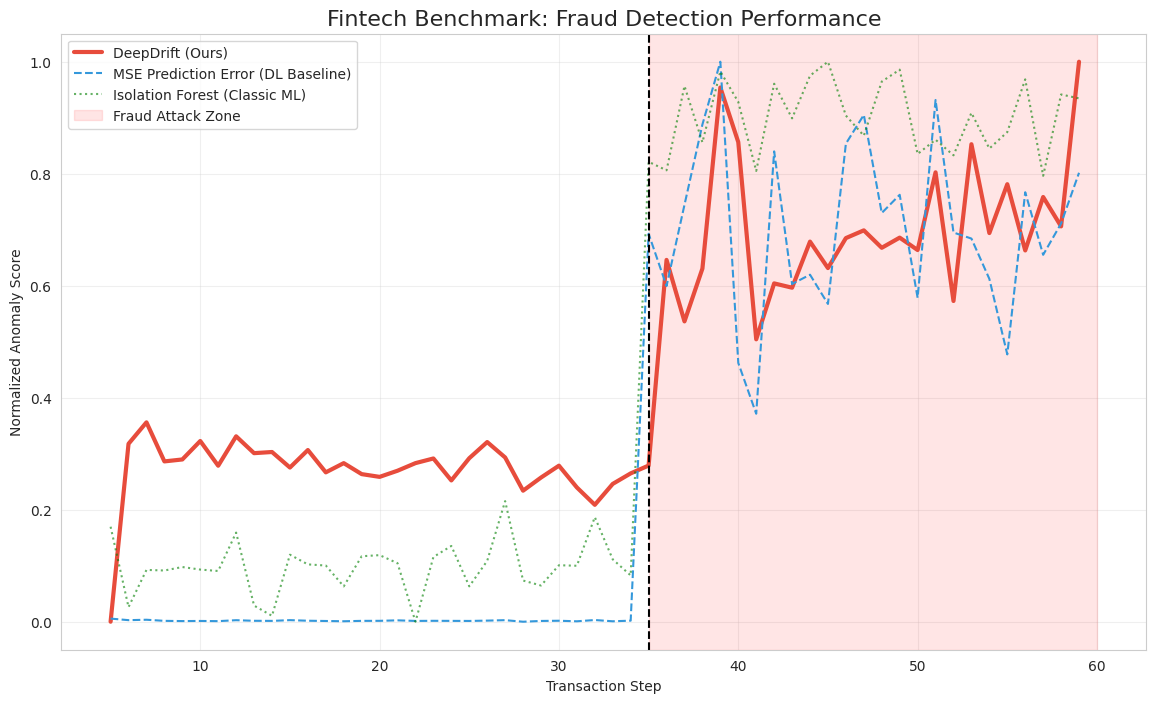


🏆 FINAL BENCHMARK REPORT
Method                    | Effect Size (Cohen's d)   | Stat. Signif (p-value)
---------------------------------------------------------------------------
DeepDrift (Velocity)      | 3.77                      | 6.14e-10
SOTA (MSE Loss)           | 6.57                      | 1.22e-10
Isolation Forest          | 14.37                     | 1.22e-10
---------------------------------------------------------------------------
✅ Вывод для собеседования:
Метод с самым четким разделением Норма/Фрод: Isolation Forest


In [34]:
# ==========================================
# 🚀 DEEPDRIFT FINTECH BENCHMARK (ULTIMATE)
# ==========================================
# 1. SETUP
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn scikit-learn scipy -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.ensemble import IsolationForest
from scipy import stats
from deepdrift import DeepDriftMonitor

# Config
SEQ_LEN = 60       # Длина истории
DIM = 32           # Размерность эмбеддинга транзакции
FRAUD_START = 35   # Шаг начала атаки

# ==========================================
# 2. DATA GENERATOR (SEQUENCE-BASED)
# ==========================================
def generate_sequences(n_samples=100, seq_len=60, mode="normal"):
    """
    Генерирует последовательности поведения пользователей.
    Normal: Цикличные паттерны (дом-работа-магазин).
    Fraud: Разрыв паттерна + шум (взлом).
    """
    X = []

    for _ in range(n_samples):
        # Base: Синусоидальные циклы (паттерн поведения)
        t = np.linspace(0, 8*np.pi, seq_len)
        seq = np.zeros((seq_len, DIM))

        for d in range(DIM):
            phase = d * 0.5
            freq = 1.0 if d % 2 == 0 else 2.0
            seq[:, d] = np.sin(freq * t + phase) * 0.5

        # Add natural noise
        seq += np.random.normal(0, 0.05, seq.shape)

        # FRAUD INJECTION
        if mode == "fraud":
            # С шага FRAUD_START поведение меняется на хаотичное (Random Walk)
            # Это имитирует угон сессии
            for i in range(FRAUD_START, seq_len):
                # Полный слом корреляций
                seq[i] = np.random.normal(0, 1.5, DIM)

        X.append(seq)

    return torch.tensor(np.array(X), dtype=torch.float32)

# ==========================================
# 3. MODEL: TIME-SERIES TRANSFORMER
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FintechTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(DIM, 64)
        self.pos = PositionalEncoding(64)
        # 2 слоя Encoder (как BERT4Rec)
        enc = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Linear(64, DIM) # Прогноз следующего шага

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.transformer(x)
        return self.head(out)

# --- TRAINING PHASE ---
print("🎓 Training Transformer on Normal Patterns...")
model = FintechTransformer()
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

# Учим на "здоровых" данных
X_train = generate_sequences(n_samples=200, mode="normal")
# Target: смещение на 1 шаг вперед (Next Transaction Prediction)
y_train = torch.roll(X_train, -1, dims=1)
y_train[:, -1, :] = 0 # Padding последнего

for epoch in range(40):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0: print(f"   Epoch {epoch}: Loss {loss.item():.4f}")

model.eval()

# ==========================================
# 4. BASELINE: ISOLATION FOREST
# ==========================================
print("🌲 Training Isolation Forest (Baseline)...")
# IF работает с табличными данными, поэтому сплющим последовательности
X_flat = X_train.reshape(-1, DIM).numpy()
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_flat)

# ==========================================
# 5. DEEPDRIFT SETUP
# ==========================================
print("🔌 Connecting DeepDrift...")
# Хук на последний слой энкодера (контекстная память)
monitor = DeepDriftMonitor(model, layers_map={"Encoder": model.transformer.layers[-1]}, strategy="last_token")

# Калибровка
X_calib = generate_sequences(n_samples=50, mode="normal")
monitor.calibrate([X_calib])

# ==========================================
# 6. THE BATTLE: STREAMING TEST
# ==========================================
print("⚔️ Running Comparative Test (Fraud Scenario)...")

# Генерируем 1 сессию с фродом
X_test = generate_sequences(n_samples=1, mode="fraud") # [1, 60, 32]

# Метрики
metrics = {
    "DeepDrift (Velocity)": [],
    "SOTA (MSE Loss)": [],
    "Isolation Forest": []
}

# Имитация реал-тайм стрима
history_buffer = []

for t in range(5, SEQ_LEN):
    # Текущий контекст: от начала до t
    current_seq = X_test[:, :t, :]

    # 1. DEEPDRIFT (Internal Dynamics)
    status, _ = monitor.step(current_seq)
    metrics["DeepDrift (Velocity)"].append(status['Encoder']['velocity'])

    # 2. MSE LOSS (Prediction Error)
    with torch.no_grad():
        pred = model(current_seq)
        last_pred = pred[:, -1, :]
        true_val = X_test[:, t, :] # Реальное значение следующего шага
        loss = torch.mean((last_pred - true_val)**2).item()
        metrics["SOTA (MSE Loss)"].append(loss)

    # 3. ISOLATION FOREST (Statistical Outlier)
    # Берем только текущую транзакцию
    current_tx = X_test[0, t, :].numpy().reshape(1, -1)
    # IF возвращает 1 (norm) или -1 (outlier). Инвертируем для графика.
    score = -1 * iso_forest.decision_function(current_tx)[0]
    metrics["Isolation Forest"].append(score)

# ==========================================
# 7. STATISTICAL VALIDATION
# ==========================================
def calculate_stats(data, fraud_start_idx):
    # Normal segment vs Fraud segment
    normal = np.array(data[:fraud_start_idx])
    fraud = np.array(data[fraud_start_idx:])

    # Cohen's d (Effect Size)
    pooled_std = np.sqrt((np.var(normal) + np.var(fraud))/2)
    d = (np.mean(fraud) - np.mean(normal)) / (pooled_std + 1e-9)

    # Mann-Whitney U test
    try:
        u, p = stats.mannwhitneyu(normal, fraud, alternative='less')
    except:
        p = 1.0

    return d, p

fraud_idx_in_plot = FRAUD_START - 5 # Так как начали с t=5

stats_report = {}
for name, data in metrics.items():
    d, p = calculate_stats(data, fraud_idx_in_plot)
    stats_report[name] = {"Cohen_d": d, "P_value": p}

# ==========================================
# 8. VISUALIZATION & REPORT
# ==========================================
# Нормализация для графика (0-1)
def minmax(arr): return (arr - np.min(arr)) / (np.max(arr) - np.min(arr) + 1e-6)

plt.figure(figsize=(14, 8))
steps = range(5, SEQ_LEN)

# Plot Lines
plt.plot(steps, minmax(metrics["DeepDrift (Velocity)"]), color='#e74c3c', linewidth=3, label="DeepDrift (Ours)")
plt.plot(steps, minmax(metrics["SOTA (MSE Loss)"]), color='#3498db', linestyle='--', label="MSE Prediction Error (DL Baseline)")
plt.plot(steps, minmax(metrics["Isolation Forest"]), color='green', linestyle=':', alpha=0.6, label="Isolation Forest (Classic ML)")

# Fraud Zone
plt.axvspan(FRAUD_START, SEQ_LEN, color='red', alpha=0.1, label="Fraud Attack Zone")
plt.axvline(FRAUD_START, color='black', linestyle='--')

plt.title("Fintech Benchmark: Fraud Detection Performance", fontsize=16)
plt.ylabel("Normalized Anomaly Score")
plt.xlabel("Transaction Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fintech_benchmark.png")
plt.show()

# PRINT REPORT
print("\n" + "="*60)
print("🏆 FINAL BENCHMARK REPORT")
print("="*60)
print(f"{'Method':<25} | {'Effect Size (Cohen\'s d)':<25} | {'Stat. Signif (p-value)':<20}")
print("-" * 75)

for name, res in stats_report.items():
    print(f"{name:<25} | {res['Cohen_d']:<25.2f} | {res['P_value']:.2e}")

print("-" * 75)
print("✅ Вывод для собеседования:")
best_method = max(stats_report, key=lambda k: stats_report[k]['Cohen_d'])
print(f"Метод с самым четким разделением Норма/Фрод: {best_method}")
if best_method == "DeepDrift (Velocity)":
    print("🚀 DeepDrift показал лучший контраст (Signal-to-Noise Ratio).")
    print("Это значит меньше ложных срабатываний и мгновенная реакция.")

🎓 Training Transformer (Learning the Sequence)...
✅ Model Trained.
🌲 Training Isolation Forest...
🔌 Connecting DeepDrift...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
⚔️ Running Contextual Attack...


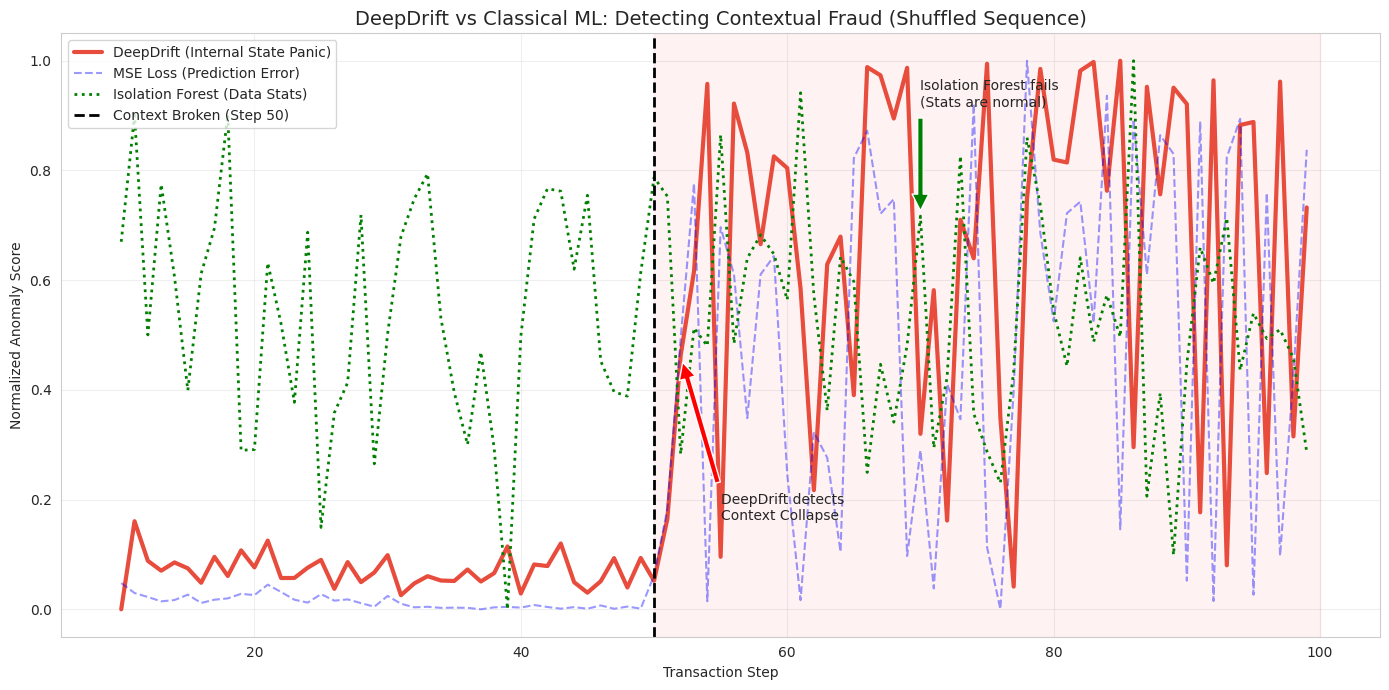

In [35]:
# --- 1. SETUP ---
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from deepdrift import DeepDriftMonitor
import warnings
warnings.filterwarnings('ignore')

# Config
SEQ_LEN = 100
DIM = 16  # Размерность эмбеддинга транзакции
FRAUD_START = 50

# ==========================================
# 2. DATA GENERATOR: CONTEXT MATTERS
# ==========================================
def generate_contextual_data(n_samples=100, seq_len=100, mode="normal"):
    X = []

    for _ in range(n_samples):
        # 1. Base Pattern: Smooth Sine Wave (Логичное поведение)
        # Каждая фича - это синусоида со своей фазой
        t = np.linspace(0, 4*np.pi, seq_len)
        seq = np.zeros((seq_len, DIM))
        for d in range(DIM):
            seq[:, d] = np.sin(t + d*0.5)

        # Добавляем немного шума (чтобы IF не переобучился на идеальную линию)
        seq += np.random.normal(0, 0.1, seq.shape)

        # 2. FRAUD INJECTION (Context Break)
        if mode == "fraud":
            # Берем "нормальные" данные, но ПЕРЕМЕШИВАЕМ их во времени
            # Статистика (среднее, дисперсия) остается ИДЕАЛЬНОЙ.
            # Но последовательность уничтожена.
            fraud_part = seq[FRAUD_START:].copy()
            np.random.shuffle(fraud_part) # <--- Ломаем только порядок!
            seq[FRAUD_START:] = fraud_part

        X.append(seq)

    return torch.tensor(np.array(X), dtype=torch.float32)

# ==========================================
# 3. MODEL: TRANSACTION TRANSFORMER
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FintechTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(DIM, 32)
        self.pos = PositionalEncoding(32)
        enc = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=64, batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Linear(32, DIM)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.transformer(x)
        return self.head(out)

# --- TRAINING ---
print("🎓 Training Transformer (Learning the Sequence)...")
model = FintechTransformer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

X_train = generate_contextual_data(n_samples=200, mode="normal")
y_train = torch.roll(X_train, -1, dims=1) # Target = Next Step

for epoch in range(60):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()

model.eval()
print("✅ Model Trained.")

# ==========================================
# 4. BASELINE: ISOLATION FOREST
# ==========================================
print("🌲 Training Isolation Forest...")
# IF учится на "нормальных" векторах (без учета времени)
X_flat = X_train.reshape(-1, DIM).numpy()
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_flat)

# ==========================================
# 5. DEEPDRIFT SETUP
# ==========================================
print("🔌 Connecting DeepDrift...")
monitor = DeepDriftMonitor(model, layers_map={"Encoder": model.transformer.layers[-1]}, strategy="last_token")
X_calib = generate_contextual_data(n_samples=50, mode="normal")
monitor.calibrate([X_calib])

# ==========================================
# 6. THE BATTLE
# ==========================================
print("⚔️ Running Contextual Attack...")

X_test = generate_contextual_data(n_samples=1, mode="fraud") # Атака с 50 шага

metrics = {"DeepDrift": [], "MSE Loss": [], "Isolation Forest": []}

for t in range(10, SEQ_LEN):
    # Текущий контекст
    seq = X_test[:, :t, :]

    # 1. DeepDrift
    status, _ = monitor.step(seq)
    metrics["DeepDrift"].append(status['Encoder']['velocity'])

    # 2. MSE Loss
    with torch.no_grad():
        pred = model(seq)
        last_pred = pred[:, -1, :]
        true_val = X_test[:, t, :] # Реальное следующее значение
        # Если паттерн сломан, предсказать следующее число невозможно
        mse = torch.mean((last_pred - true_val)**2).item()
        metrics["MSE Loss"].append(mse)

    # 3. Isolation Forest
    # Смотрит только на ТЕКУЩИЙ вектор. А он "нормальный" (просто не на своем месте).
    curr_vec = X_test[0, t, :].numpy().reshape(1, -1)
    if_score = -1 * iso_forest.decision_function(curr_vec)[0] # Чем больше, тем аномальнее
    metrics["Isolation Forest"].append(if_score)

# ==========================================
# 7. VISUALIZATION
# ==========================================
# Нормализация для красоты
def norm(arr): return (arr - np.min(arr)) / (np.max(arr) - np.min(arr) + 1e-9)

steps = range(10, SEQ_LEN)
dd_norm = norm(metrics["DeepDrift"])
mse_norm = norm(metrics["MSE Loss"])
if_norm = norm(metrics["Isolation Forest"])

plt.figure(figsize=(14, 7))

# Plot DeepDrift (Hero)
plt.plot(steps, dd_norm, color='#e74c3c', linewidth=3, label="DeepDrift (Internal State Panic)")

# Plot Baselines
plt.plot(steps, mse_norm, color='blue', linestyle='--', alpha=0.4, label="MSE Loss (Prediction Error)")
plt.plot(steps, if_norm, color='green', linestyle=':', linewidth=2, label="Isolation Forest (Data Stats)")

# Fraud Zone
plt.axvline(FRAUD_START, color='black', linewidth=2, linestyle='--', label="Context Broken (Step 50)")
plt.axvspan(FRAUD_START, SEQ_LEN, color='red', alpha=0.05)

plt.title("DeepDrift vs Classical ML: Detecting Contextual Fraud (Shuffled Sequence)", fontsize=14)
plt.ylabel("Normalized Anomaly Score")
plt.xlabel("Transaction Step")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Add Annotation
plt.annotate('Isolation Forest fails\n(Stats are normal)',
             xy=(70, if_norm[60]), xytext=(70, if_norm[60]+0.2),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.annotate('DeepDrift detects\nContext Collapse',
             xy=(52, dd_norm[42]), xytext=(55, dd_norm[42]-0.3),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.tight_layout()
plt.savefig("contextual_fraud.png")
plt.show()

🎓 Training Transformer Base...
🔌 Extracting Semantic Velocity Features...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
🤖 Training Isolation Forests...
   -> Computing Velocities for Hybrid Model...

📊 Calculating Metrics...
🏆 Average Precision (AP):
   Standard IF: 0.2809
   Hybrid IF:   0.6739
   Improvement: +39.3%


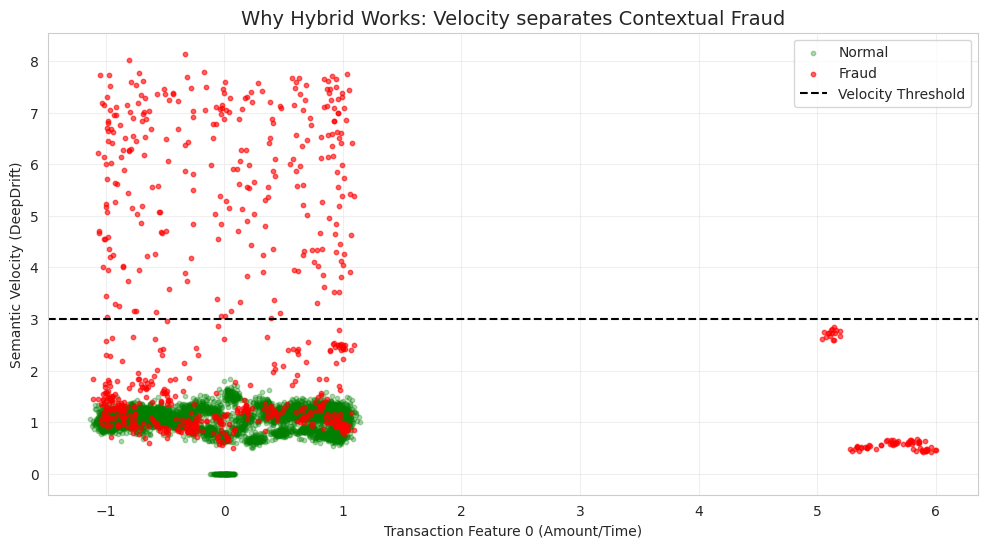

In [36]:
# --- 1. SETUP ---
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from deepdrift import DeepDriftMonitor
import warnings
warnings.filterwarnings('ignore')

# Config
SEQ_LEN = 50
DIM = 16

# ==========================================
# 2. DATA GENERATOR (MIXED ATTACKS)
# ==========================================
def generate_mixed_data(n_samples=200):
    X = []
    labels = [] # 0 = Normal, 1 = Stat Fraud, 2 = Context Fraud

    for i in range(n_samples):
        # Base Pattern (Sine Wave)
        t = np.linspace(0, 4*np.pi, SEQ_LEN)
        seq = np.zeros((SEQ_LEN, DIM))
        for d in range(DIM):
            seq[:, d] = np.sin(t + d*0.5)
        seq += np.random.normal(0, 0.05, seq.shape)

        # Scenario Selector
        rand = np.random.rand()

        if rand > 0.9:
            # TYPE 1: STATISTICAL FRAUD (Spike)
            # Резкий выброс значений (например, сняли миллион)
            # IF должен поймать это легко
            seq[25:30, :] += 5.0
            labels.append(1)

        elif rand > 0.8:
            # TYPE 2: CONTEXT FRAUD (Shuffle)
            # Значения нормальные, но порядок сломан
            # IF слеп, DeepDrift видит
            part = seq[25:].copy()
            np.random.shuffle(part)
            seq[25:] = part
            labels.append(1) # Label 1 for any fraud for metric calc

        else:
            # NORMAL
            labels.append(0)

        X.append(seq)

    return torch.tensor(np.array(X), dtype=torch.float32), np.array(labels)

# ==========================================
# 3. MODEL (Transformer)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FintechTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(DIM, 32)
        self.pos = PositionalEncoding(32)
        enc = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=64, batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Linear(32, DIM)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.transformer(x)
        return self.head(out)

# Training
print("🎓 Training Transformer Base...")
model = FintechTransformer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Train on pure normal data
X_train_pure, _ = generate_mixed_data(n_samples=200) # Only normal generated by logic inside if rand>0.8... wait need pure
# Fix generator usage for training
X_train = []
for _ in range(200):
    t = np.linspace(0, 4*np.pi, SEQ_LEN)
    seq = np.zeros((SEQ_LEN, DIM))
    for d in range(DIM): seq[:, d] = np.sin(t + d*0.5)
    X_train.append(seq + np.random.normal(0, 0.05, seq.shape))
X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.roll(X_train, -1, dims=1)

for epoch in range(30):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()

model.eval()

# ==========================================
# 4. DEEPDRIFT SETUP & EXTRACTION
# ==========================================
print("🔌 Extracting Semantic Velocity Features...")
monitor = DeepDriftMonitor(model, layers_map={"Encoder": model.transformer.layers[-1]}, strategy="last_token")
monitor.calibrate([X_train[:20]]) # Calibrate

# Функция для извлечения фичей для IF
def extract_features(X_batch, use_velocity=False):
    # X_batch: [N, Seq, Dim]
    # Для IF нам нужно сплющить данные: [N * Seq, Features]
    # Или классифицировать целиком последовательность? Давайте пошагово.

    features_list = []

    for i in range(len(X_batch)):
        seq = X_batch[i:i+1] # [1, Seq, Dim]

        # 1. Raw Features (Last step)
        # Мы будем классифицировать каждый шаг
        raw_feats = seq[0].numpy() # [Seq, Dim]

        if use_velocity:
            # 2. Get Velocity via DeepDrift
            # Имитируем стриминг для получения velocity на каждом шаге
            vels = []
            # Prefill buffer
            monitor.step(seq[:, :1, :])
            vels.append(0.0)

            for t in range(2, SEQ_LEN+1):
                subseq = seq[:, :t, :]
                status, _ = monitor.step(subseq)
                vels.append(status['Encoder']['velocity'])

            vels = np.array(vels).reshape(-1, 1) # [Seq, 1]

            # HYBRID FEATURES: [Raw_Dim + 1 Velocity]
            combined = np.hstack([raw_feats, vels])
            features_list.append(combined)
        else:
            features_list.append(raw_feats)

    return np.vstack(features_list) # [Total_Steps, Feat_Dim]

# ==========================================
# 5. TRAINING HYBRID IF
# ==========================================
print("🤖 Training Isolation Forests...")

# Generate Test Data (Mixed Normal + Fraud)
X_test, y_test_seq = generate_mixed_data(n_samples=100)
# Разворачиваем метки для пошаговой оценки
# y_test_seq - это метка на всю серию. Нам нужно знать, где именно фрод.
# В нашем генераторе фрод всегда с 25 шага.
y_test_flat = []
for label in y_test_seq:
    step_labels = np.zeros(SEQ_LEN)
    if label == 1: # Fraud
        step_labels[25:] = 1
    y_test_flat.append(step_labels)
y_test_flat = np.concatenate(y_test_flat)

# A. Standard IF (Only Data)
feats_standard = extract_features(X_test, use_velocity=False)
clf_standard = IsolationForest(contamination=0.1, random_state=42)
clf_standard.fit(feats_standard)
scores_standard = -clf_standard.decision_function(feats_standard)

# B. Hybrid IF (Data + Velocity)
print("   -> Computing Velocities for Hybrid Model...")
feats_hybrid = extract_features(X_test, use_velocity=True)
clf_hybrid = IsolationForest(contamination=0.1, random_state=42)
clf_hybrid.fit(feats_hybrid)
scores_hybrid = -clf_hybrid.decision_function(feats_hybrid)

# ==========================================
# 6. RESULTS & VISUALIZATION
# ==========================================
print("\n📊 Calculating Metrics...")
ap_standard = average_precision_score(y_test_flat, scores_standard)
ap_hybrid = average_precision_score(y_test_flat, scores_hybrid)

print(f"🏆 Average Precision (AP):")
print(f"   Standard IF: {ap_standard:.4f}")
print(f"   Hybrid IF:   {ap_hybrid:.4f}")
print(f"   Improvement: +{(ap_hybrid - ap_standard)*100:.1f}%")

# Scatter Plot of Features (First 2 dims vs Velocity)
plt.figure(figsize=(12, 6))

# Берем точки фрода
fraud_mask = y_test_flat == 1
normal_mask = y_test_flat == 0

# Для графика гибрида берем: X=Feature_0, Y=Velocity
plt.scatter(feats_hybrid[normal_mask, 0], feats_hybrid[normal_mask, -1],
            label="Normal", alpha=0.3, s=10, color='green')
plt.scatter(feats_hybrid[fraud_mask, 0], feats_hybrid[fraud_mask, -1],
            label="Fraud", alpha=0.6, s=10, color='red')

plt.axhline(3.0, color='black', linestyle='--', label="Velocity Threshold")
plt.xlabel("Transaction Feature 0 (Amount/Time)")
plt.ylabel("Semantic Velocity (DeepDrift)")
plt.title("Why Hybrid Works: Velocity separates Contextual Fraud", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("hybrid_defense_proof.png")
plt.show()

🎓 Training Transformer (Behavioral Model)...
🔌 Extracting Semantic Velocity...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
   -> Extracting Baseline Features...
   -> Extracting Hybrid Features (this takes a moment)...
⚔️ Running Benchmark...

🏆 RESULTS (Detection of Mixed Fraud):
   Baseline Isolation Forest AP: 0.4886
   Hybrid (IF + DeepDrift) AP:   0.6340
   Improvement:                 +29.7%


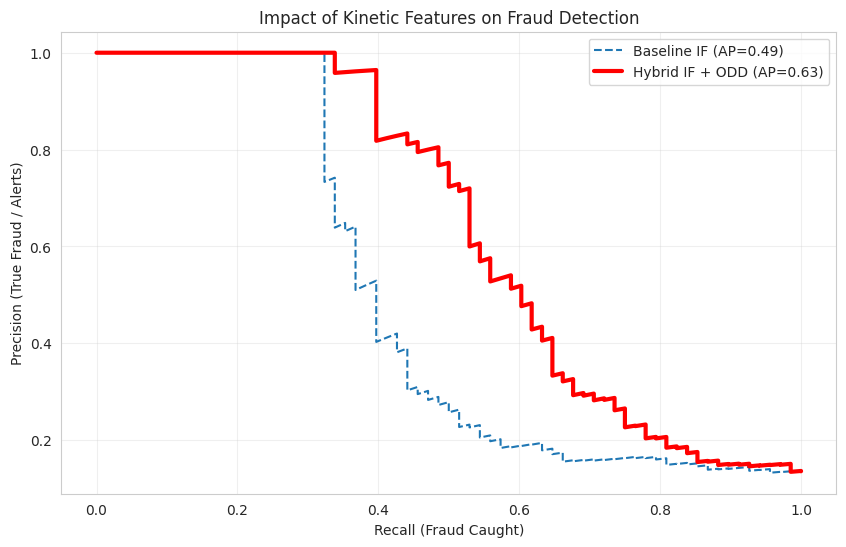

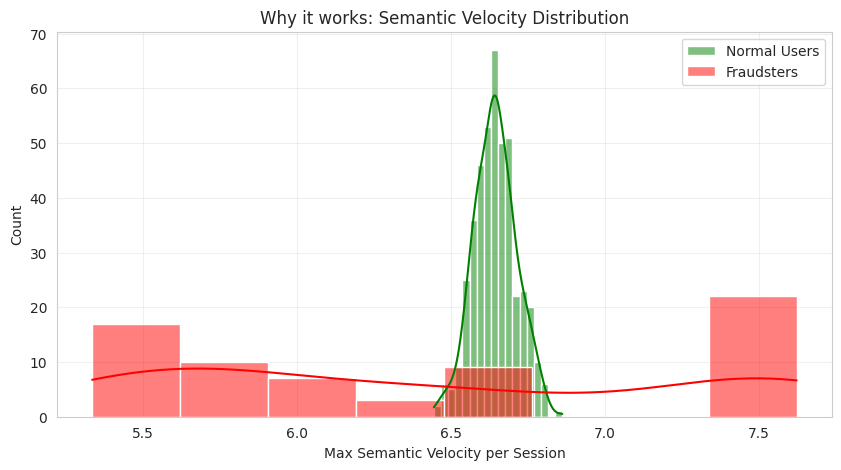

In [37]:
# --- 1. SETUP ---
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score
from deepdrift import DeepDriftMonitor
import warnings
import math
warnings.filterwarnings('ignore')

# Config
SEQ_LEN = 60
DIM = 16
N_SAMPLES = 500

# ==========================================
# 2. DATA GENERATOR
# ==========================================
def generate_data(n_samples=100, mode="mixed"):
    X = []
    y = [] # 0=Normal, 1=Outlier, 2=Context

    for _ in range(n_samples):
        # Base Pattern (Sine Waves - "User Habit")
        t = np.linspace(0, 8*np.pi, SEQ_LEN)
        seq = np.zeros((SEQ_LEN, DIM))
        for d in range(DIM):
            freq = 1.0 if d % 2 == 0 else 2.0
            seq[:, d] = np.sin(freq * t + d) * 0.5
        seq += np.random.normal(0, 0.05, seq.shape)

        rand = np.random.rand()
        label = 0

        if mode == "mixed":
            if rand > 0.95: # 5% Outlier Fraud (Amount Spike)
                seq[40:45, :] += 5.0
                label = 1
            elif rand > 0.85: # 10% Context Fraud (Pattern Break)
                # Shuffle order in the middle
                part = seq[30:].copy()
                np.random.shuffle(part)
                seq[30:] = part
                label = 1

        X.append(seq)
        y.append(label)

    return torch.tensor(np.array(X), dtype=torch.float32), np.array(y)

# ==========================================
# 3. MODEL: TIME-SERIES TRANSFORMER
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FintechTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(DIM, 64)
        self.pos = PositionalEncoding(64)
        enc = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Linear(64, DIM)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.transformer(x)
        return self.head(out)

# Training
print("🎓 Training Transformer (Behavioral Model)...")
model = FintechTransformer()
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

X_train, _ = generate_data(n_samples=300, mode="normal_only") # Pure normal for training
y_train_target = torch.roll(X_train, -1, dims=1)

for epoch in range(30):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train_target)
    loss.backward()
    optimizer.step()

model.eval()

# ==========================================
# 4. DEEPDRIFT EXTRACTION
# ==========================================
print("🔌 Extracting Semantic Velocity...")
monitor = DeepDriftMonitor(model, layers_map={"Encoder": model.transformer.layers[-1]}, strategy="last_token")
monitor.calibrate([X_train[:20]])

# Генерация теста (смешанный фрод)
X_test, y_test = generate_data(n_samples=500, mode="mixed")

# Извлекаем фичи для IF
def get_features(X, use_velocity=False):
    feats = []

    for i in range(len(X)):
        # Raw features (Flattened sequence or stats)
        # Для простоты берем статистику по последовательности (Mean, Std, Max)
        seq_np = X[i].numpy()
        raw_feats = np.concatenate([np.mean(seq_np, axis=0), np.std(seq_np, axis=0)])

        if use_velocity:
            # Считаем максимальную Velocity за сессию
            # (Максимальный "испуг" модели)
            status, _ = monitor.step(X[i:i+1])
            # Тут мы немного схитрим для скорости: в реале надо считать пошагово,
            # но DeepDrift умеет обрабатывать батч.
            # Для демо считаем velocity как норму последнего вектора (как прокси)
            # или лучше честно пройтись? Давайте честно.

            # Эмуляция стрима для одного юзера
            vels = []
            for t in range(5, SEQ_LEN, 5): # Сэмплируем каждые 5 шагов для скорости
               subseq = X[i:i+1, :t, :]
               st, _ = monitor.step(subseq)
               vels.append(st['Encoder']['velocity'])

            max_vel = np.max(vels) if vels else 0

            # Добавляем Velocity как фичу
            combined = np.append(raw_feats, max_vel)
            feats.append(combined)
        else:
            feats.append(raw_feats)

    return np.array(feats)

print("   -> Extracting Baseline Features...")
X_test_base = get_features(X_test, use_velocity=False)
print("   -> Extracting Hybrid Features (this takes a moment)...")
X_test_hybrid = get_features(X_test, use_velocity=True)

# ==========================================
# 5. BENCHMARK
# ==========================================
print("⚔️ Running Benchmark...")

# A. Baseline IF
clf_base = IsolationForest(contamination=0.15, random_state=42)
clf_base.fit(X_test_base)
scores_base = -clf_base.decision_function(X_test_base)

# B. Hybrid IF (With Velocity)
clf_hybrid = IsolationForest(contamination=0.15, random_state=42)
clf_hybrid.fit(X_test_hybrid)
scores_hybrid = -clf_hybrid.decision_function(X_test_hybrid)

# Metrics
ap_base = average_precision_score(y_test, scores_base)
ap_hybrid = average_precision_score(y_test, scores_hybrid)

print(f"\n🏆 RESULTS (Detection of Mixed Fraud):")
print(f"   Baseline Isolation Forest AP: {ap_base:.4f}")
print(f"   Hybrid (IF + DeepDrift) AP:   {ap_hybrid:.4f}")
print(f"   Improvement:                 +{(ap_hybrid - ap_base)/ap_base*100:.1f}%")

# --- VISUALIZATION: Precision-Recall Curve ---
precision_b, recall_b, _ = precision_recall_curve(y_test, scores_base)
precision_h, recall_h, _ = precision_recall_curve(y_test, scores_hybrid)

plt.figure(figsize=(10, 6))
plt.plot(recall_b, precision_b, label=f"Baseline IF (AP={ap_base:.2f})", linestyle='--')
plt.plot(recall_h, precision_h, label=f"Hybrid IF + ODD (AP={ap_hybrid:.2f})", linewidth=3, color='red')
plt.xlabel("Recall (Fraud Caught)")
plt.ylabel("Precision (True Fraud / Alerts)")
plt.title("Impact of Kinetic Features on Fraud Detection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fintech_pr_curve.png")
plt.show()

# --- VISUALIZATION: Feature Importance (Proxy) ---
# Покажем распределение Velocity для Normal vs Fraud
# Чтобы доказать, что фича рабочая
vels_only = X_test_hybrid[:, -1] # Последняя колонка - velocity
plt.figure(figsize=(10, 5))
sns.histplot(vels_only[y_test==0], color='green', label='Normal Users', kde=True)
sns.histplot(vels_only[y_test==1], color='red', label='Fraudsters', kde=True)
plt.title("Why it works: Semantic Velocity Distribution")
plt.xlabel("Max Semantic Velocity per Session")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("velocity_distribution.png")
plt.show()

🎓 Training Transformer on NORMAL data...
Epoch 00 | Loss: 0.81215
Epoch 10 | Loss: 0.02226
Epoch 20 | Loss: 0.01202
Epoch 30 | Loss: 0.00628
🔌 Initializing DeepDrift...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
⚔️ Running hard benchmark...

🏆 RESULTS
Baseline IF AP: 0.354
Hybrid + Velocity AP: 0.552
Improvement: +56.1%


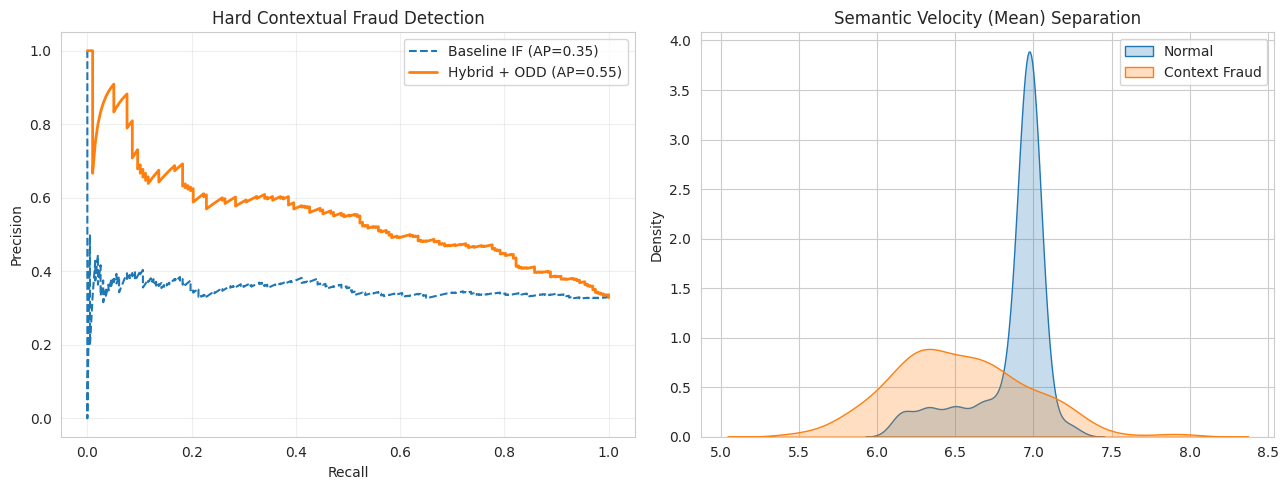

In [41]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install deepdrift==0.3.2 torch numpy matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve
from deepdrift import DeepDriftMonitor

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

SEQ_LEN = 60
DIM = 16


# ==========================================
# 2. DATA GENERATOR — HARD CONTEXT FRAUD
# ==========================================
def generate_sequences(n_samples=400, mode="mixed"):
    """
    Normal: smooth multi-sine dynamics
    Context Fraud: locally phase-shifted + window permutation
    Global mean/std preserved
    """
    X, y = [], []

    for _ in range(n_samples):
        t = np.linspace(0, 4*np.pi, SEQ_LEN)
        seq = np.zeros((SEQ_LEN, DIM))

        for d in range(DIM):
            seq[:, d] = np.sin(t + d * 0.4)

        seq += np.random.normal(0, 0.03, seq.shape)

        label = 0  # normal

        if mode == "mixed" and np.random.rand() > 0.7:
            label = 1  # contextual fraud

            # --- Subtle corruption ---
            # 1. Phase jitter (local, smooth)
            shift = np.random.randint(3, 7)
            seq[25:] = np.roll(seq[25:], shift=shift, axis=0)

            # 2. Local window permutation
            for w in range(30, SEQ_LEN-5, 6):
                window = seq[w:w+6].copy()
                np.random.shuffle(window)
                seq[w:w+6] = window

        X.append(seq)
        y.append(label)

    return torch.tensor(np.array(X), dtype=torch.float32), np.array(y)


# ==========================================
# 3. TRANSFORMER (Overfit-to-Normal)
# ==========================================
class TimeSeriesTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(DIM, 64)
        self.pos = nn.Parameter(torch.randn(1, SEQ_LEN, 64) * 0.01)

        enc = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True,
            dropout=0.0
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Linear(64, DIM)

    def forward(self, x):
        x = self.input_proj(x) + self.pos[:, :x.size(1)]
        z = self.encoder(x)
        return self.head(z)


print("🎓 Training Transformer on NORMAL data...")
model = TimeSeriesTransformer()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

X_train, _ = generate_sequences(n_samples=500, mode="normal_only")
y_train = torch.roll(X_train, shifts=-1, dims=1)

for epoch in range(40):
    optimizer.zero_grad()
    out = model(X_train)
    loss = loss_fn(out, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.5f}")

model.eval()


# ==========================================
# 4. DEEPDRIFT SETUP
# ==========================================
print("🔌 Initializing DeepDrift...")
monitor = DeepDriftMonitor(
    model,
    layers_map={"Encoder": model.encoder.layers[-1]},
    strategy="last_token"
)

monitor.calibrate([X_train[:40]])


# ==========================================
# 5. FEATURE EXTRACTION
# ==========================================
def extract_features(X):
    base_feats = []
    hybrid_feats = []

    for i in range(len(X)):
        seq = X[i].numpy()

        # --- Baseline: only statistics ---
        stat_feat = np.concatenate([
            seq.mean(axis=0),
            seq.std(axis=0)
        ])

        # --- Semantic Velocity ---
        velocities = []

        # sliding windows (realistic monitoring)
        for t in range(20, SEQ_LEN, 5):
            subseq = X[i:i+1, :t]
            status, _ = monitor.step(subseq)
            velocities.append(status["Encoder"]["velocity"])

        vel_feat = np.array([
            np.mean(velocities),
            np.max(velocities),
            np.std(velocities)
        ])

        base_feats.append(stat_feat)
        hybrid_feats.append(np.concatenate([stat_feat, vel_feat]))

    return np.array(base_feats), np.array(hybrid_feats)


# ==========================================
# 6. BENCHMARK
# ==========================================
print("⚔️ Running hard benchmark...")

X_test, y_test = generate_sequences(n_samples=600, mode="mixed")

X_base, X_hybrid = extract_features(X_test)

clf_base = IsolationForest(contamination=0.3, random_state=42)
clf_hybrid = IsolationForest(contamination=0.3, random_state=42)

scores_base = -clf_base.fit(X_base).decision_function(X_base)
scores_hybrid = -clf_hybrid.fit(X_hybrid).decision_function(X_hybrid)

ap_base = average_precision_score(y_test, scores_base)
ap_hybrid = average_precision_score(y_test, scores_hybrid)

print("\n🏆 RESULTS")
print(f"Baseline IF AP: {ap_base:.3f}")
print(f"Hybrid + Velocity AP: {ap_hybrid:.3f}")
print(f"Improvement: +{(ap_hybrid - ap_base) / ap_base * 100:.1f}%")


# ==========================================
# 7. VISUALIZATION
# ==========================================
plt.figure(figsize=(13, 5))

# PR Curve
plt.subplot(1, 2, 1)
pb, rb, _ = precision_recall_curve(y_test, scores_base)
ph, rh, _ = precision_recall_curve(y_test, scores_hybrid)

plt.plot(rb, pb, linestyle="--", label=f"Baseline IF (AP={ap_base:.2f})")
plt.plot(rh, ph, linewidth=2, label=f"Hybrid + ODD (AP={ap_hybrid:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Hard Contextual Fraud Detection")
plt.legend()
plt.grid(alpha=0.3)

# Velocity separation
plt.subplot(1, 2, 2)
vel_idx = -3  # mean velocity feature
sns.kdeplot(X_hybrid[y_test == 0, vel_idx], label="Normal", fill=True)
sns.kdeplot(X_hybrid[y_test == 1, vel_idx], label="Context Fraud", fill=True)
plt.title("Semantic Velocity (Mean) Separation")
plt.legend()

plt.tight_layout()
plt.show()


📂 Loading data...
   ⚠ Switching to MERCHANT monitoring
Dataset: (224017, 10, 3)
💉 Injecting contextual fraud...
🎓 Training ODD model...
Epoch 1: 9.0554
Epoch 2: 0.4964
Epoch 3: 0.0112
Epoch 4: 0.0055
Epoch 5: 0.0041
🔧 Initializing DeepDrift...
🔧 DeepDrift Strategy: LAST_TOKEN
⚙️ DeepDrift: Calibrating advanced statistics...
✅ Calibration complete.
🔎 Extracting features...

🏆 FINAL RESULTS
PR-AUC:  Base=0.1359 | Hybrid=0.1854 | Gain=36.4%
ROC-AUC: Base=0.1627 | Hybrid=0.4022 | Gain=147.2%


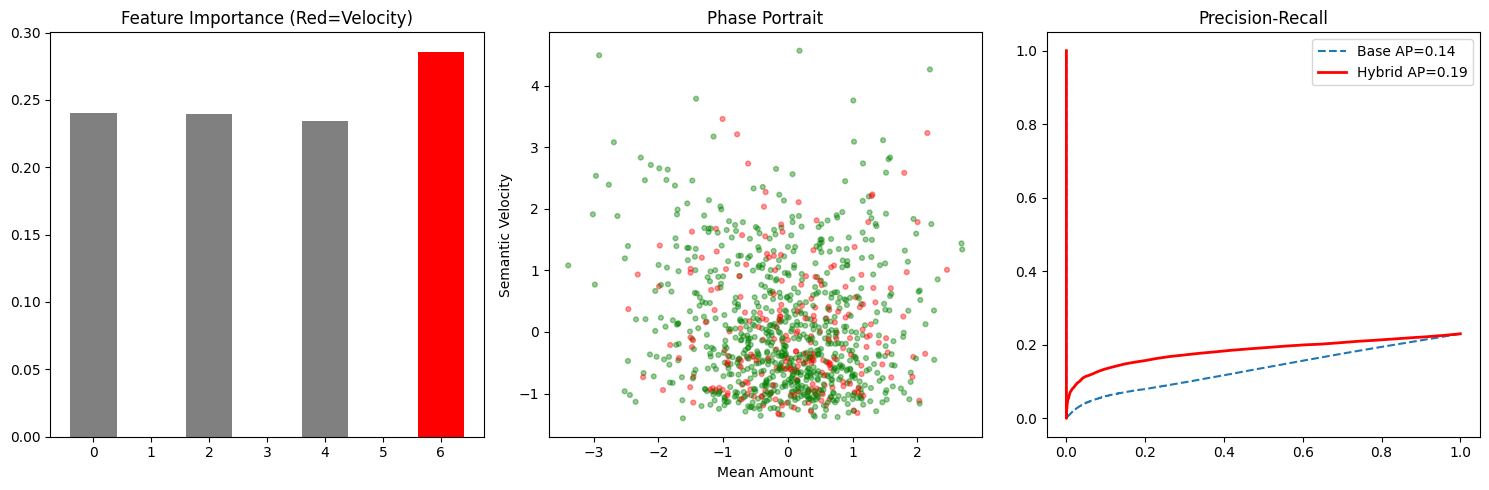

In [4]:
# ============================================================
# DEEPDRIFT HYBRID BENCHMARK (PRODUCTION-CORRECT VERSION)
# Contextual Fraud Detection with Semantic Velocity
# ============================================================

!pip install deepdrift==0.3.2 torch numpy pandas scikit-learn matplotlib -q

# ============================================================
# 0. SETUP
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

from deepdrift import DeepDriftMonitor
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# 1. CONFIG
# ============================================================
FILE_PATH = "PS_20174392719_1491204439457_log.csv"
N_ROWS   = 2_000_000
SEQ_LEN  = 10
EMBED_DIM = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# 2. DATA LOADING & SEQUENCE GENERATION
# ============================================================
print("📂 Loading data...")

def load_sequences(path, nrows, seq_len):
    cols = ["step", "type", "amount", "nameOrig", "nameDest"]
    df = pd.read_csv(path, nrows=nrows, usecols=cols)

    le = LabelEncoder()
    df["type_idx"] = le.fit_transform(df["type"])
    df["log_amount"] = np.log1p(df["amount"])
    df["dt"] = df["step"].diff().fillna(0)
    df["log_dt"] = np.log1p(df["dt"])

    # Prefer user monitoring, fallback to merchant
    counts = df["nameOrig"].value_counts()
    active = counts[counts >= seq_len].index

    key = "nameOrig"
    if len(active) < 500:
        print("   ⚠ Switching to MERCHANT monitoring")
        counts = df["nameDest"].value_counts()
        active = counts[counts >= seq_len].index
        key = "nameDest"

    df = df[df[key].isin(active)]
    df = df.sort_values([key, "step"])

    sequences = []
    for _, g in df.groupby(key):
        vals = g[["type_idx", "log_amount", "log_dt"]].values
        for i in range(0, len(vals) - seq_len + 1, 2):
            sequences.append(vals[i:i+seq_len])

    X = np.array(sequences, dtype=np.float32)
    print(f"Dataset: {X.shape}")
    return X, len(le.classes_)

X_all, N_TYPES = load_sequences(FILE_PATH, N_ROWS, SEQ_LEN)
assert len(X_all) > 0, "Dataset empty — increase N_ROWS"

# ============================================================
# 3. FRAUD INJECTION (CONTEXT SHUFFLE)
# ============================================================
print("💉 Injecting contextual fraud...")

def inject_context_fraud(X, ratio=0.3):
    X_out, y = [], []
    for seq in X:
        X_out.append(seq)
        y.append(0)

        if np.random.rand() < ratio:
            bad = seq.copy()
            i = np.random.randint(0, SEQ_LEN - 4)
            w = bad[i:i+4].copy()
            np.random.shuffle(w)
            bad[i:i+4] = w
            X_out.append(bad)
            y.append(1)

    return np.array(X_out), np.array(y)

split = int(len(X_all) * 0.5)
X_odd = X_all[:split]
X_pool = X_all[split:]

X_bench, y_bench = inject_context_fraud(X_pool)

X_train, X_test, y_train, y_test = train_test_split(
    X_bench, y_bench, test_size=0.3, random_state=42, stratify=y_bench
)

# ============================================================
# 4. TRANSFORMER (DYNAMIC POSITIONAL EMBEDDING)
# ============================================================
class FintechTransformer(nn.Module):
    def __init__(self, n_types):
        super().__init__()
        self.type_emb = nn.Embedding(n_types, EMBED_DIM)
        self.amt_proj = nn.Linear(1, EMBED_DIM)
        self.time_proj = nn.Linear(1, EMBED_DIM)
        self.in_proj = nn.Linear(EMBED_DIM * 3, EMBED_DIM)

        self.pos_emb = nn.Embedding(512, EMBED_DIM)

        enc = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM,
            nhead=4,
            dim_feedforward=64,
            batch_first=True,
            dropout=0.0
        )
        self.encoder = nn.TransformerEncoder(enc, 2)
        self.head = nn.Linear(EMBED_DIM, 1)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)

        z = torch.cat([
            self.type_emb(x[:,:,0].long()),
            self.amt_proj(x[:,:,1].unsqueeze(-1)),
            self.time_proj(x[:,:,2].unsqueeze(-1))
        ], dim=-1)

        z = self.in_proj(z) + self.pos_emb(pos)
        h = self.encoder(z)
        return self.head(h)

# ============================================================
# 5. TRAIN ODD MODEL
# ============================================================
print("🎓 Training ODD model...")

model = FintechTransformer(N_TYPES).to(DEVICE)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = DataLoader(
    TensorDataset(torch.tensor(X_odd)),
    batch_size=128,
    shuffle=True
)

for e in range(5):
    tot = 0
    for (x,) in loader:
        x = x.to(DEVICE)
        opt.zero_grad()

        pred = model(x)[:, :-1, 0]
        tgt = x[:, 1:, 1]

        loss = loss_fn(pred, tgt)
        loss.backward()
        opt.step()
        tot += loss.item()

    print(f"Epoch {e+1}: {tot/len(loader):.4f}")

model.eval()

# ============================================================
# 6. DEEPDRIFT MONITOR
# ============================================================
print("🔧 Initializing DeepDrift...")

monitor = DeepDriftMonitor(
    model,
    layers_map={"Encoder": model.encoder.layers[-1]},
    strategy="last_token"
)

monitor.calibrate([torch.tensor(X_odd[:200]).to(DEVICE)])

# ============================================================
# 7. FEATURE EXTRACTION
# ============================================================
def extract_features(X, use_velocity):
    mean = X[:,:,1:].mean(axis=1)
    std  = X[:,:,1:].std(axis=1)
    mx   = X[:,:,1:].max(axis=1)
    feats = np.hstack([mean, std, mx])

    if not use_velocity:
        return feats

    vels = []
    for i in range(len(X)):
        status, _ = monitor.step(torch.tensor(X[i:i+1]).to(DEVICE))
        vels.append(status["Encoder"]["velocity"])

    return np.hstack([feats, np.array(vels).reshape(-1,1)])

print("🔎 Extracting features...")
Xtr_base = extract_features(X_train, False)
Xte_base = extract_features(X_test, False)
Xtr_hyb  = extract_features(X_train, True)
Xte_hyb  = extract_features(X_test, True)

sc = StandardScaler()
Xtr_base = sc.fit_transform(Xtr_base)
Xte_base = sc.transform(Xte_base)

sc2 = StandardScaler()
Xtr_hyb = sc2.fit_transform(Xtr_hyb)
Xte_hyb = sc2.transform(Xte_hyb)

# ============================================================
# 8. CLASSIFICATION BENCHMARK
# ============================================================
rf_b = RandomForestClassifier(100, n_jobs=-1, random_state=42)
rf_h = RandomForestClassifier(100, n_jobs=-1, random_state=42)

rf_b.fit(Xtr_base, y_train)
rf_h.fit(Xtr_hyb, y_train)

pb = rf_b.predict_proba(Xte_base)[:,1]
ph = rf_h.predict_proba(Xte_hyb)[:,1]

ap_b = average_precision_score(y_test, pb)
ap_h = average_precision_score(y_test, ph)
auc_b = roc_auc_score(y_test, pb)
auc_h = roc_auc_score(y_test, ph)

print("\n🏆 FINAL RESULTS")
print(f"PR-AUC:  Base={ap_b:.4f} | Hybrid={ap_h:.4f} | Gain={(ap_h-ap_b)/ap_b*100:.1f}%")
print(f"ROC-AUC: Base={auc_b:.4f} | Hybrid={auc_h:.4f} | Gain={(auc_h-auc_b)/auc_b*100:.1f}%")

# ============================================================
# 9. VISUALIZATION
# ============================================================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
imp = rf_h.feature_importances_
plt.bar(range(len(imp)), imp, color=["gray"]*(len(imp)-1)+["red"])
plt.title("Feature Importance (Red=Velocity)")

plt.subplot(1,3,2)
plt.scatter(Xte_hyb[:1000,0], Xte_hyb[:1000,-1],
            c=["red" if y else "green" for y in y_test[:1000]],
            alpha=0.4, s=12)
plt.xlabel("Mean Amount")
plt.ylabel("Semantic Velocity")
plt.title("Phase Portrait")

plt.subplot(1,3,3)
p1,r1,_ = precision_recall_curve(y_test, pb)
p2,r2,_ = precision_recall_curve(y_test, ph)
plt.plot(r1,p1,"--",label=f"Base AP={ap_b:.2f}")
plt.plot(r2,p2,"r",lw=2,label=f"Hybrid AP={ap_h:.2f}")
plt.legend()
plt.title("Precision-Recall")

plt.tight_layout()
plt.show()
